#Final capstone project
#module 2-analytics pipeline
#titanic survival data story
**objective**explore the titanic dataset,clean missing values,analyze passenger survival pattterns, and prepare the dataset for machine learning.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\ALEKHYA\Desktop\final-ai-ml-capstone-project\analytics
['01_data_story.ipynb', '02_ml_pipeline.ipynb', 'titanic.csv', 'titanic_cleaned.csv']


In [4]:
#load titanic dataset
df=sns.load_dataset("titanic")
 
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.to_csv("titanic.csv",index=False)
print("Titanic Dataset Loaded Successfully!")

Titanic Dataset Loaded Successfully!


In [6]:
print("Shape of Dataset:", df.shape)
print("\nDataset Information:")
df.info()
print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset: (891, 15)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##step 1:Missing value analysis
the titanic dataset contains missing values in a few columns.According to the project requirement, we first calculate the percentage of missing values for every column and then decide an appropriate cleaning strategy.

In [7]:
#calculate missing values percentage
missing_values = (df.isnull().sum() / len(df)) * 100
missing_df=pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":missing_values.round(2)
    })
#show only columns with missing values
missing_df=missing_df[missing_df["Missing Values"]>0]
print("Missing Value Summary:")
display(missing_df)


Missing Value Summary:


,Missing Values,Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


##step2:Missing value handling strategy
the cleaning strategy follows the assignment rule:
-Less than 5% missing values -> Drop rows.
-Between 5% and 30% missing values ->Median or Mode imputation.
-Very high missing values -> Drop the column and justify the decision.

In [8]:
#create copy for cleaning
clean_df=df.copy()
#Age:Median imputation
clean_df["age"].fillna(clean_df["age"].median())
#Embarked:Drop rows(very small percentage missing)
clean_df=clean_df.dropna(subset=["embarked"])

#Embark Town:Fill with most frequent(Mode) value
clean_df["embark_town"]=clean_df["embark_town"].fillna(clean_df["embark_town"].mode()[0])

#Deck:Drop column because it has too many missing values
clean_df=clean_df.drop(columns=["deck"])

print("Cleaning Completed")
print(clean_df.shape)

Cleaning Completed
(889, 14)


##step 3:Verify missing values after cleaning
After applying the cleaning strategy, we verify that missing value have been handled correctly.

In [9]:
#check remaining missing values.
remaining_missing = clean_df.isnull().sum()
remaining_missing=remaining_missing[remaining_missing>0]
print("Remaining Missing Values")
display(remaining_missing)

Remaining Missing Values


age    177
dtype: int64

##step4:Save cleaned dataset
the cleaned Titanic dataset is saved for the modelling stage.

In [30]:
clean_df.to_csv("titanic_cleaned.csv",index=False)
print("Titanic cleaned dataset saved successfully!")

Titanic cleaned dataset saved successfully!


#step5: Univariate Analysis
Univariate analysis studies one variable at a time.In this notebok,we analyze the distribution of Age and Fare using histograms and box plots.

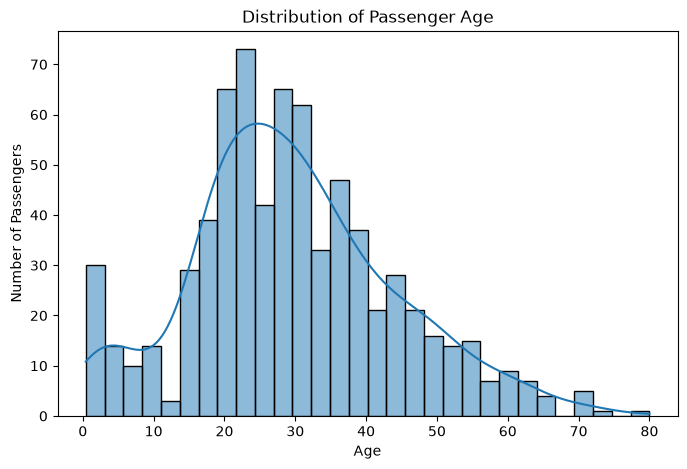

In [10]:
#Histogram of Age
plt.figure(figsize=(8,5))
sns.histplot(clean_df["age"],bins=30, kde=True)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

###Interpretation
The box plotbshows the distribution of passengers are between about 20 and 40 years old,and a few values outside the whiskers are potential outliers.

In [11]:
print(clean_df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')


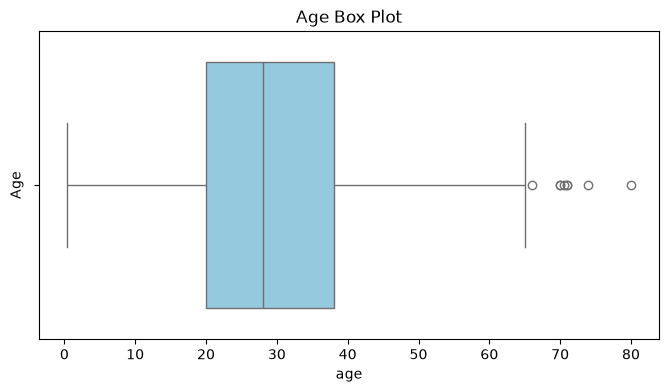

In [13]:
#Box plot of Age
plt.figure(figsize=(8,4))
sns.boxplot(x=clean_df["age"],color="skyblue")
plt.title("Age Box Plot")
plt.ylabel("Age")
plt.show()

###Interpretation
-The box plot shows a few passengers with very high ages.
-These values appear as outliers above the upper whisker.
-Most passengers fall within the middle age range.

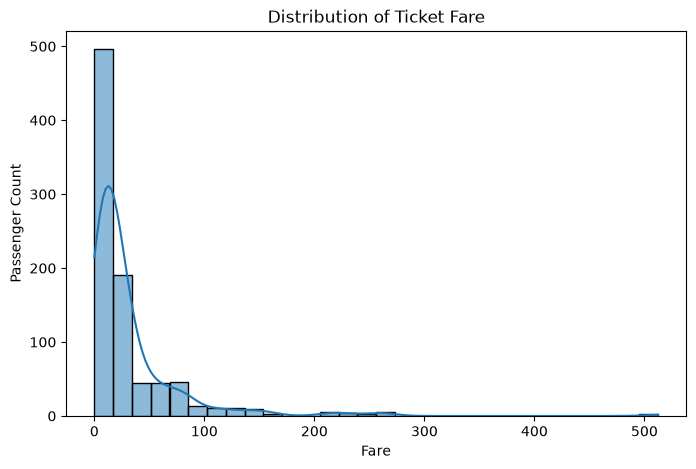

In [14]:
#Histogram fare
plt.figure(figsize=(8,5))
sns.histplot(clean_df["fare"],bins=30,kde=True)
plt.title("Distribution of Ticket Fare")
plt.xlabel("Fare")
plt.ylabel("Passenger Count")
plt.show()

###Interpretation
-Most ticket fares are concentrated at lower values.
-A few passengers paid very high fares.
-The fare distribution is strongly right-skewed.

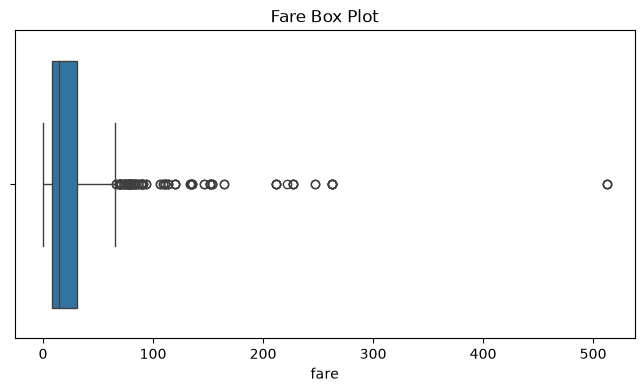

In [15]:
#Box plot for fare
plt.figure(figsize=(8,4))
sns.boxplot(x=clean_df["fare"])
plt.title("Fare Box Plot")
plt.show()

###Interpretation
-Many high-fare passengers appear as outliers.
-Most passengerrs purchased low-cost tickets.
-This indicates Fare has a long right tail.

In [16]:
#Mean,Median,Mode
print("Age Statistics")
print("Mean :",clean_df["age"].mean())
print("Median :",clean_df["age"].median())
print("Mode :",clean_df["age"].mode()[0])

print("\nFare Statistics")
print("Mean :",clean_df["fare"].mean())
print("Median :",clean_df["fare"].median())
print("Mode :",clean_df["fare"].mode()[0])




Age Statistics
Mean : 29.64209269662921
Median : 28.0
Mode : 24.0

Fare Statistics
Mean : 32.09668087739032
Median : 14.4542
Mode : 8.05


###Interpretation
-Age mean and median are close, showing a moderate spread.
-Fare mean is much higher than the median because of expensive tickets.
-This confirms Fare is positively skewed.

In [18]:
#IQR for Fare
Q1=clean_df["fare"].quantile(0.25)
Q3=clean_df["fare"].quantile(0.75)

IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

outliers=clean_df[
    (clean_df["fare"] < lower_limit) |
    (clean_df["fare"] > upper_limit)
]

print("Number of Fare Outliers:", len(outliers))

Number of Fare Outliers: 114


###Interpretation
-The IQR identifies unusually expensive ticket fares.
-These observations are genuine passengers are not removed in this analysis.
-Outliers detection helps understand the spread of ticket prices.

#step6: Bivariate Analysis
Bivariate analysis means the realtionship between two variables. here, we analyze how passenger survival changes with gender,passenger class, and embarkation port.

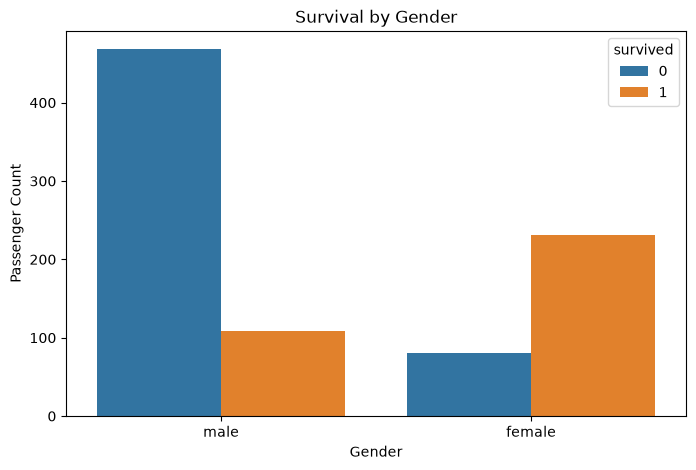

In [19]:
#survival by gender
plt.figure(figsize=(8,5))
sns.countplot(
    data=clean_df,
    x="sex",
    hue="survived"
)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")
plt.show()

###Interpretation
-Female passengers survived in much larger numbers than male passengers.
-male passengers had a higher number of non-survivors.
-Gender appears to have a strong relationship with survival.

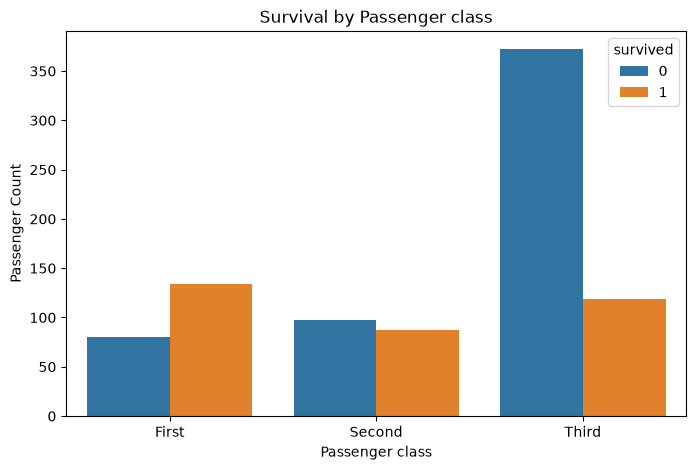

In [20]:
#Survival by passenger class
plt.figure(figsize=(8,5))
sns.countplot(
    data=clean_df,
    x="class",
    hue="survived"
)
plt.title("Survival by Passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Passenger Count")
plt.show()


###Interpretation
-First-class passengers show a higher survival count.
-Third-class passengers show the largest number of non-survivors.
-Passenger class is an important feature for predicting survival.

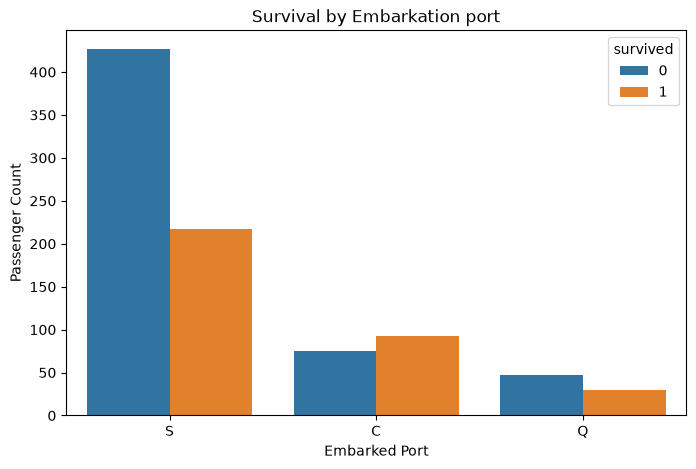

In [21]:
#Survival by Embarkation port
plt.figure(figsize=(8,5))
sns.countplot(
    data=clean_df,
    x="embarked",
    hue="survived"
)
plt.title("Survival by Embarkation port")
plt.xlabel("Embarked Port")
plt.ylabel("Passenger Count")
plt.show()


###Interpretation
-Passengers emabrked from southampton (s) were the largest group.
-survival counts vary across embarkation ports.
-Embarkation location may provide useful information for prediction.

##step 7:Correlation Heatmap
The correlation heatmap helps identify relationships among numerical variables.

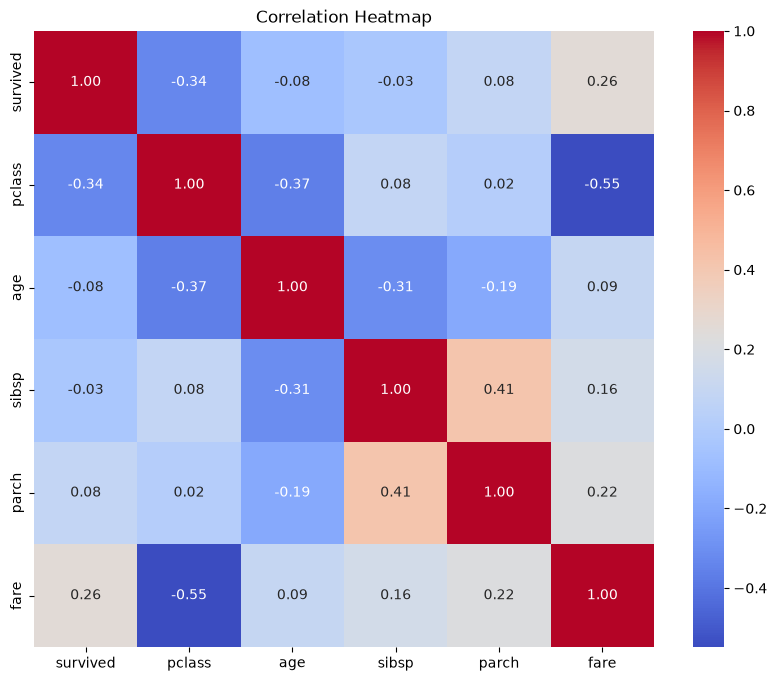

In [22]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df=clean_df.select_dtypes(include=["number"])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

###Interpretation
-survival has a postive correlation with fare.
-passenger calss variables shoe correlation with survival.
-some numerical features have weak correlations, indicating limited linear  realtionships.

##step8:Pairplot Analysis
Pairplo visualizes pairwise relationships among important numerical variables.

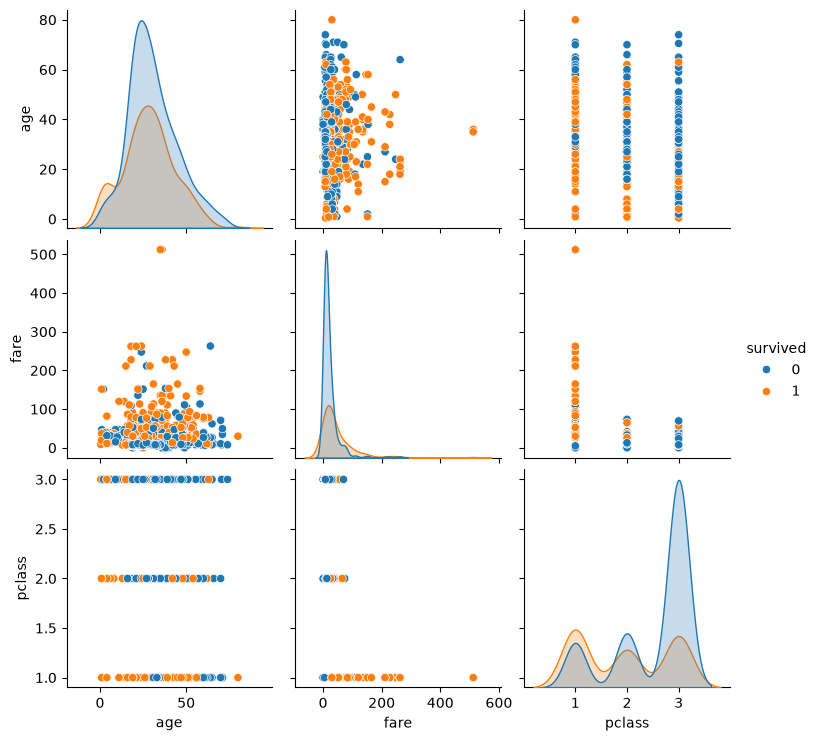

In [27]:
#Pairplot
pair_columns=["survived","age","fare","pclass"]
sns.pairplot(
    clean_df[pair_columns],
    hue="survived"

)
 
plt.show()

###Interpretation
-Fare and passenger class show visible difference between survivors and non-survivors.
-Younger and older passengers overlap,indicating age alone is not a strong predictor.
-pairplot provides a quick overview of feature relationships.

##step 9:Survival percentage by category.
This table summarizes survival percentages for important categories.

In [28]:
#survival percentage by gender
gender_survival=(
    clean_df.groupby("sex")["survived"].mean().mul(100).round(2).reset_index()
)
gender_survival.columns=["Gender","survival Percentage"]
display(gender_survival)

,Gender,survival Percentage
0,female,74.04
1,male,18.89


###Interpretation
-Female passengers have a much higher survival percentage.
--Male passengers have a lower survival percentage.
-This supports the visual observation from the count plot.

##step 10:Feature Engineering
-Feature Engineering creates new useful features from existing data.These features improve the performance of machine learning models.

In [29]:
#create family size feature
clean_df["family_size"]=clean_df["sibsp"]+clean_df["parch"]+1
print(clean_df[["sibsp", "parch", "family_size"]].head())

   sibsp  parch  family_size
0      1      0            2
1      1      0            2
2      0      0            1
3      1      0            2
4      0      0            1


###Interpretation 
-A new feature is called family_size is created by adding the number of siblings/spouses(sibsp),parent/children(parch),and the passenger(+1).This feature helps identify whether a passenger was travelling alone or with family,which may improve the machine learning models performance.

##step 11:create is alone feature
create a new feature to identify passengers travelling alone.

In [30]:
#create is_alone feature
clean_df["is_alone"]=(clean_df["family_size"]==1).astype(int)
clean_df[["family_size", "is_alone"]].head()

,family_size,is_alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


###Interpretation
Passengers with 'family_size=1' are travelling alone,so 'is_alone' is set to 1.Otherwise, it is 0.

#step 11:Feature selection
we select the important features required for the machine learning pipeline.

In [32]:
#select important features
features=["pclass", "sex", "age", "fare", "embarked", "family_size", "is_alone"]
X=clean_df[features]
y=clean_df["survived"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (889, 7)
Target Shape: (889,)


#step 12:seperate numerical and categorical features
machine learning preprocessing treats numerical and categorical columns differently.

In [33]:
#numerical and categorical columns
numeric_features=[
    "age",
    "fare",
    "family_size"
]
categorical_features=[
    "sex",
    "embarked",
    "pclass",
    "is_alone"
]
print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['age', 'fare', 'family_size']
Categorical Features: ['sex', 'embarked', 'pclass', 'is_alone']


#step 13:Train-Test Split
The dataset is divided into training and testing sets using stratified sampling.

In [34]:
from sklearn.model_selection import train_test_split
#Stratified Train-Test Split
X_train, X_test, y_train, y_test =train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (711, 7)
Testing Shape: (178, 7)


#step 14: Save prepared dataset
The cleaned and feature-engineered dataset is saved for the machine learning notebook.

In [36]:
clean_df.to_csv(
    "titanic_feature_engineered.csv",index=False
)
print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!
